In [5]:
from boututils.datafile import DataFile
from boutdata.collect import collect
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import os, sys, pathlib
import platform
import traceback
import xarray as xr
import xbout
from pathlib import Path
import xhermes as xh

sys.path.append(os.path.join(r"/Users/lloyd/Documents/hermes_dir/analysis/sdtools"))
# sys.path.append(os.path.join(r"/Users/lloyd/Documents/hermes_dir/analysis/my_notebooks/notebooks/hermes-3/transients"))
sys.path.append(os.path.join(r"/Users/lloyd/Documents/hermes_dir/analysis/notebooks/hermes-3/general_functions"))


from plotting_functions import *
from convergence_functions import * 

from hermes3.case_db import *
from hermes3.casedeck import*
from hermes3.load import *
from hermes3.named_selections import *
from hermes3.plotting import *
from hermes3.grid_fields import *
from hermes3.accessors import *
from hermes3.utils import *
from hermes3.fluxes import *
from hermes3.selectors import *
from hermes3.front_tracking import *
from hermes3.neutral_transport import *

# from code_comparison.code_comparison import *
from code_comparison.solps_pp import *
from code_comparison.solps_variables import *
# from code_comparison.viewer_2d import *

from solps_funcs import *

# from hermes3.balance1d import *

# plt.style.use('ggplot')
plt.rcParams.update({'font.size': 10})
linewidth = 3
markersize = 15



# plt.style.use('ggplot')
mpl.style.use('default')
mpl.rcParams["axes.edgecolor"] = "black"
mpl.rcParams["axes.linewidth"] = 1
mpl.rcParams['xtick.labelsize'] = 18
mpl.rcParams['ytick.labelsize'] = 18
mpl.rcParams['axes.grid'] = True
mpl.rcParams.update({'font.size': 16})



%load_ext autoreload
%autoreload 2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# I/O

In [6]:
case = SOLPScase('/Users/lloyd/Documents/hermes_dir/york-step_analysis_intro/data/solps')

raw_balance = nc.Dataset('/Users/lloyd/Documents/hermes_dir/york-step_analysis_intro/data/solps/balance.nc')



# Calculate $\lambda$ for real this time

## $\lambda_q$

Specific function to find $\lambda_q$, as per DM

## Find peak poloidal power

In [7]:
for i in range(10):
    fline_peak = case.get_1d_poloidal_data(
        params = ['fhtx', 'R'],
        region = 'outer_lower',
        sepadd = i,
        guards = False
)

    peak_index = np.argmax(fline_peak['fhtx'])
    print(peak_index)

15
15
15
15
14
13
13
13
14
14


Exponential fit:
lambda_q = 1.929 mm
HWHM = 1.337 mm
amplitude = 1.56e+07 W/m^2


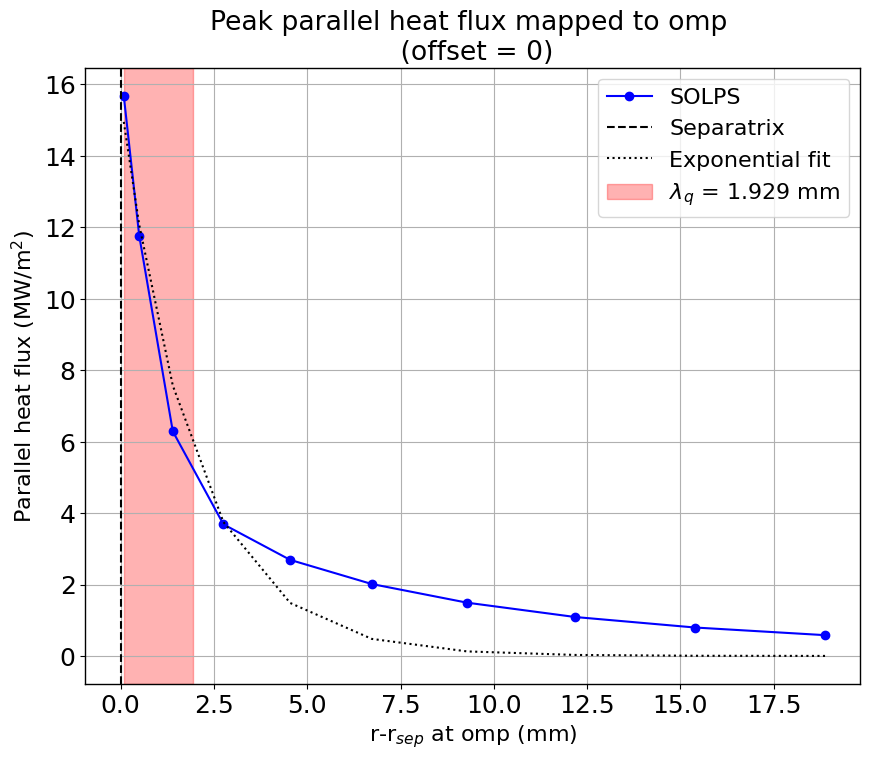

ValueError: Not enough points after filtering to fit. map_to='outer_lower_xpoint', map_offset=0, range=(0.0, 0.02)

In [ ]:
from math import exp


def get_lambda_q(case, poloidal_offset, map_to = 'omp',map_offset = 0, range=(0.0, None), plot = False):

    # get heat flux at peak parallel power (normally just above the X-point)
    fline_peaks = case.get_1d_radial_data(
        params = ['fhtx', 'R'],
        region = 'omp',
        sepadd = 1,
        poloidal_offset = poloidal_offset,
        guards = False
    )

    fline_R = case.get_1d_poloidal_data(
        params = ['R'],
        region = 'outer_lower',
        sepadd = 0,
        guards = False
    )

    # get radial dist at omp which we map the parallel power to
    fline_omp = case.get_1d_radial_data(
        params = [],
        #region = 'omp',
        region = map_to,
        poloidal_offset = map_offset,
        sepadd = 0,
        guards = False
    )

    if range[0] is not None:
        sep_indx = np.searchsorted(fline_omp['dist'], range[0], side = 'left')
        fline_omp = fline_omp.iloc[sep_indx:].reset_index(drop=True)
        fline_peaks = fline_peaks.iloc[sep_indx:].reset_index(drop=True)

    if range[1] is not None:
        upper_indx = np.searchsorted(fline_omp['dist'], range[1], side = 'right')
        fline_omp = fline_omp.iloc[:upper_indx].reset_index(drop=True)
        fline_peaks = fline_peaks.iloc[:upper_indx].reset_index(drop=True)

    # print(fline_R['R'].values[poloidal_offset])
    # print(fline_R['R'].values[-1])

    q_parallel = (fline_peaks['fhtx']/fline_peaks['apar'])*(fline_R['R'].values[poloidal_offset]/fline_R['R'].values[-1])
    omp_dist = fline_omp['dist']

    # fig,ax = plt.subplots()
    # ax.plot(omp_dist, q_parallel)
    # plt.show()


    try:
        def fit_exp(r,a,lmq):
            return a*np.exp(-r/lmq)

        p0_exp = [q_parallel[0], 0.006]
        popt_exp, pcov_exp = curve_fit(fit_exp, omp_dist, q_parallel, p0=p0_exp)

        lambda_q = popt_exp[1]
        hwhm = lambda_q * np.log(2)

        print(f'Exponential fit:')
        print(f'lambda_q = {lambda_q*1000:.3f} mm')
        print(f'HWHM = {hwhm*1000:.3f} mm')
        print(f'amplitude = {popt_exp[0]:.2e} W/m^2')
        exponential_success = True
    except RuntimeError as e:
        print(f"Runtime error: {e}")
        print("Fitting failed. Returning None for lambda_q.")
        exponential_success = False


    if plot:
        fig, ax = plt.subplots(figsize = (10, 8))
        ax.plot(omp_dist*1000, q_parallel*1e-6, label='SOLPS', color = 'blue', marker = 'o')
        ax.axvline(0, color = 'black', linestyle = '--', label = 'Separatrix')
        if exponential_success: 
            ax.plot(omp_dist*1000, fit_exp(omp_dist, *popt_exp)*1e-6, label='Exponential fit', color = 'black', linestyle = ':')
            ax.axvspan(omp_dist[0]*1000, popt_exp[1]*1000, color='red', alpha=0.3, label=rf'$\lambda_q$ = {lambda_q*1000:.3f} mm')
        # if gaussian_success:
        #     ax.plot(omp_dist, gaussian_fwhm(omp_dist, *popt_gauss), label='Gaussian fit')
        ax.legend()
        ax.set_xlabel(r'r-r$_{sep}$' + f' at {map_to} (mm)')
        ax.set_ylabel(r'Parallel heat flux (MW/m$^2$)')
        ax.set_title(f'Peak parallel heat flux mapped to {map_to} \n (offset = {map_offset})')
        plt.show()
        

get_lambda_q(case, poloidal_offset=15, map_to = 'omp', range=(0.0, 0.02), plot = True)